**In this Notebook, I am getting familiar with the [modern dataset (Chen)](https://zenodo.org/records/7306199) (download the *.nc* file).**

This dataset is not a direct output from isotope-enabled GCMs. Instead, it has been generated through data fusion and bias correction techniques based on GCM outputs. In other words, post-processing methods were applied to the model outputs to bring the simulations closer to observational data. This dataset is 1870–2017 at a monthly scale.

First, we import useful libraries and read the netCTF4 file with xarray to get a Dataset object. 

In [2]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np
import plotly as px
import cartopy.crs as ccrs
import seaborn as sns
sns.set_style('darkgrid')
fn = '../data/modern/PrecipOxygenIso_mainlandCHINA_1870to2017_v2.nc'

In [3]:
with xr.open_dataset(filename_or_obj=fn, engine='netcdf4',decode_times=False) as file:
    print(file)
    # We need the data array containing variable d180p
    d18Op = file.d18Op

<xarray.Dataset> Size: 79MB
Dimensions:  (time: 1776, lon: 87, lat: 64)
Coordinates:
  * lat      (lat) float64 512B 53.1 52.44 51.83 51.24 ... 21.63 21.12 20.61
  * lon      (lon) float64 696B 73.74 74.4 75.06 75.72 ... 131.4 132.7 134.1
  * time     (time) float64 14kB 1.0 2.0 3.0 ... 1.774e+03 1.775e+03 1.776e+03
Data variables:
    d18Op    (time, lon, lat) float64 79MB ...


In [4]:
# if needed, the DataArray can be converted in a pandas series.
d18Op_series = d18Op.to_series() # convert to multi-index series 
d18Op_series = d18Op_series.loc[~ d18Op_series.isna()] # drop nan values 

Now, we can try to plot the data by setting different spatio-temporal ranges.

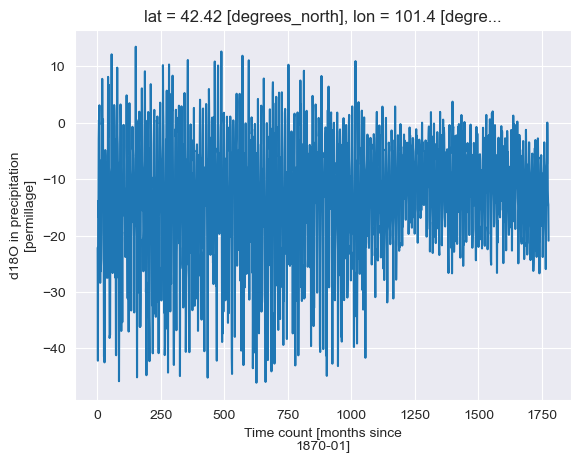

In [5]:
testloc_d18Op = d18Op.isel(lat=20,lon=42)
testloc_d18Op.plot()
plt.show()

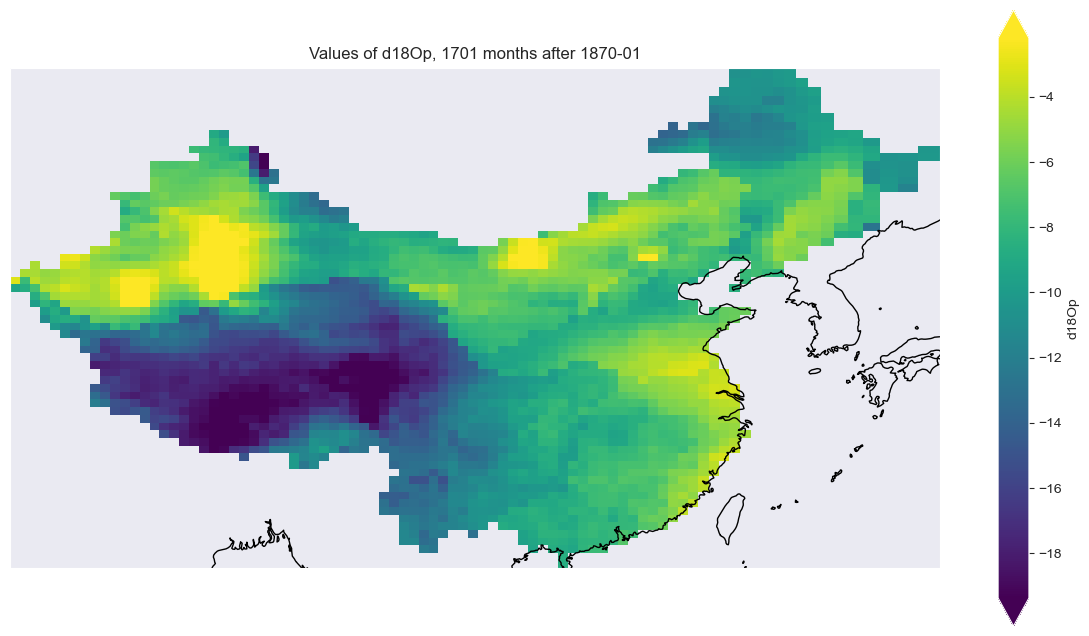

In [6]:
# Plot with cartopy
da_sel = d18Op.transpose('time','lat','lon').isel(time=1700) #1775
fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
da_sel.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={"label": da_sel.name},
    robust=True
)

# Add map features
ax.coastlines()
ax.set_title(f"Values of d18Op, {str(int(da_sel.time.values))} months after 1870-01")
plt.savefig("../output/itrace_artifacts_example.png",dpi=400)
plt.show()

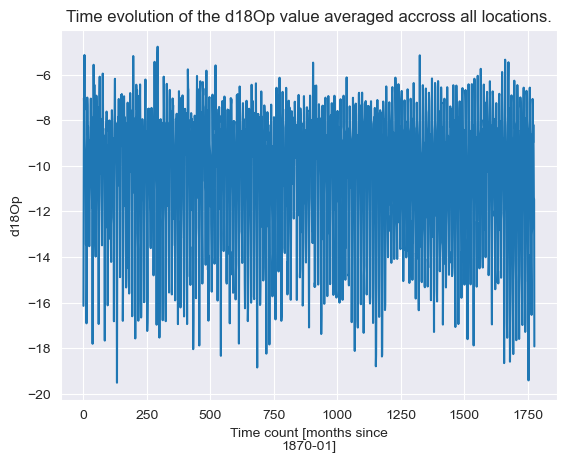

In [7]:
# Mean across all lat/lon
global_mean = d18Op.median(dim=("lat", "lon"))
global_mean.plot.line(x="time")
plt.title('Time evolution of the d18Op value averaged accross all locations.')
plt.show()

### Variogram 

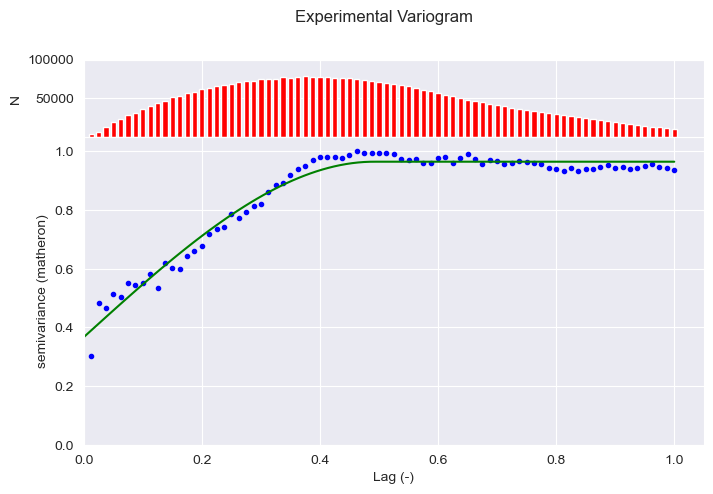

In [19]:
import skgstat as skg
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

da = d18Op.isel(time=1413)
lats = da['lat'].values
lons = da['lon'].values

lon_grid, lat_grid = np.meshgrid(lons, lats)
coords = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
values = da.values.ravel()

mask = ~np.isnan(values)
coords_valid = coords[mask]
values_valid = values[mask]

# Project lon/lat in mercator coordinates
gdf = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_valid],
    crs="EPSG:4326"
)
gdf_proj = gdf.to_crs(epsg=3857)
coords_proj = np.array([(p.x, p.y) for p in gdf_proj.geometry])

#shift/log-transform values 
# if np.any(values_valid <= 0):
#     shift = np.abs(np.min(values_valid)) + 1
#     values_valid = np.log(values_valid + shift)

# Use coords_proj in Variogram
V = skg.Variogram(
    coords_proj,
    values_valid,
    n_lags=80,
    maxlag=6000000,
    model='spherical',
    use_nugget=True,
    normalize=True
)

# Plot
fig = V.plot(show=False, grid=False)
fig.suptitle('Experimental Variogram')
fig.show()
